In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
%matplotlib inline


In [3]:
X,y = make_blobs(n_samples = 1000, n_features = 2, centers = 3)

In [4]:
X

array([[ 2.13025339,  1.56686292],
       [-4.68445291,  9.37621633],
       [-4.91083913,  8.24000227],
       ...,
       [-6.60949466,  9.81672081],
       [ 3.16574332,  0.53263398],
       [-4.78411507, -0.95489034]], shape=(1000, 2))

In [5]:
y

array([0, 1, 1, 1, 2, 1, 0, 1, 2, 1, 2, 2, 2, 1, 1, 0, 2, 2, 2, 2, 1, 0,
       0, 2, 2, 0, 2, 2, 0, 1, 0, 0, 0, 2, 1, 2, 0, 1, 1, 0, 2, 0, 0, 0,
       1, 2, 1, 2, 2, 2, 2, 0, 1, 2, 2, 0, 2, 1, 0, 2, 2, 2, 2, 2, 0, 1,
       2, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 2, 0, 2, 1, 0, 0, 2, 0, 1, 2,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 2, 0, 2, 2, 1, 0, 0, 0,
       2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 0, 0, 0, 2, 1, 0, 1, 0, 1, 2, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 2, 1, 0, 0, 0,
       1, 0, 0, 0, 2, 1, 1, 2, 1, 2, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0,
       2, 1, 0, 0, 0, 2, 1, 1, 0, 1, 1, 1, 2, 0, 0, 2, 0, 2, 1, 2, 0, 2,
       1, 0, 0, 2, 2, 0, 0, 0, 0, 1, 1, 2, 1, 2, 1, 0, 2, 1, 2, 2, 0, 1,
       0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 1, 0, 0, 0, 1, 0, 2, 2, 1, 2, 1,
       1, 2, 2, 0, 1, 2, 2, 2, 0, 0, 1, 1, 1, 0, 2, 2, 0, 2, 0, 0, 1, 2,
       1, 2, 2, 2, 2, 1, 2, 1, 0, 0, 0, 2, 1, 1, 1, 2, 2, 2, 1, 1, 0, 1,
       0, 2, 0, 1, 1, 0, 0, 2, 0, 0, 2, 2, 2, 0, 2,

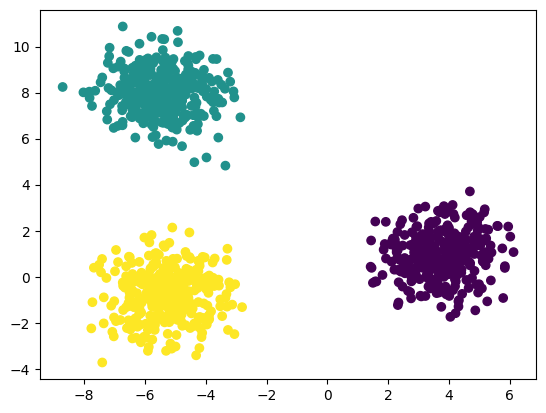

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
# standardaize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [9]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# finding  k and implementing k-means
from sklearn.cluster import KMeans

In [11]:
# elbow method to find k
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:

wcss

[1339.9999999999998,
 573.7253877424243,
 78.50875439175796,
 69.32614752869743,
 59.829060047837,
 53.65562525043089,
 44.91135257145808,
 39.78306922950285,
 36.78531228834251,
 31.345077438988035]

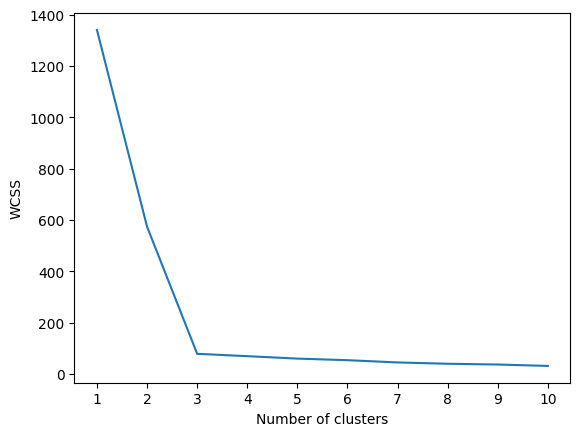

In [13]:
# elbow curve plotting
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [14]:
# As we now understood our k to be 3 we apply kmeans with k=3
kmeans = KMeans(n_clusters=3,init='k-means++')

In [15]:
kmeans.fit_predict(X_train_scaled)

array([2, 0, 1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2,
       2, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 2, 2, 0, 2, 1, 2, 2, 1, 2,
       2, 2, 0, 2, 1, 2, 0, 1, 0, 2, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 0,
       1, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 2, 1, 0, 2, 0, 1, 0, 1, 0, 1, 1,
       2, 2, 0, 1, 2, 0, 2, 0, 2, 0, 1, 2, 0, 0, 0, 2, 2, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 0, 0, 1, 2, 0, 2, 2, 0, 1,
       2, 2, 2, 0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 0, 0, 1, 0, 1, 2, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 2, 2, 1, 0, 2, 2, 1, 2, 0, 1, 2, 0, 2, 0, 2, 2,
       0, 1, 0, 2, 2, 2, 0, 2, 2, 1, 1, 1, 0, 1, 2, 2, 0, 2, 0, 1, 1, 1,
       0, 0, 0, 1, 2, 0, 2, 0, 1, 2, 0, 0, 0, 1, 0, 2, 2, 0, 1, 0, 0, 1,
       2, 0, 1, 1, 0, 2, 1, 0, 2, 0, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 0, 1,
       0, 1, 0, 2, 2, 1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 0, 2, 0, 1, 2, 0, 2,
       0, 1, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 1, 1, 2,

In [16]:
y_pred = kmeans.predict(X_test_scaled)

In [17]:
y_pred

array([2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 0, 0, 2, 2, 2,
       2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 0, 2, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1,
       0, 2, 2, 1, 1, 2, 0, 2, 0, 2, 0, 0, 1, 0, 2, 0, 1, 1, 0, 0, 2, 0,
       0, 0, 2, 0, 1, 1, 2, 2, 1, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 0, 1, 2,
       0, 2, 2, 2, 2, 1, 2, 1, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 0, 2, 1,
       1, 1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 1, 0, 0, 0, 2, 2, 1, 0, 1, 2, 2,
       1, 0, 1, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 1, 2, 1,
       2, 0, 1, 2, 1, 2, 1, 0, 2, 2, 0, 2, 1, 0, 2, 1, 0, 0, 2, 0, 2, 0,
       2, 1, 1, 0, 2, 1, 1, 1, 2, 2, 0, 1, 0, 1, 0, 2, 1, 1, 2, 0, 1, 2,
       2, 0, 1, 2, 0, 0, 0, 2, 2, 0, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 1, 0,
       2, 0, 1, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 0, 1, 0, 2, 0, 1, 1, 0, 1,
       1, 2, 1, 2, 0, 2, 2, 1, 0, 1, 0, 2, 1, 2, 2,

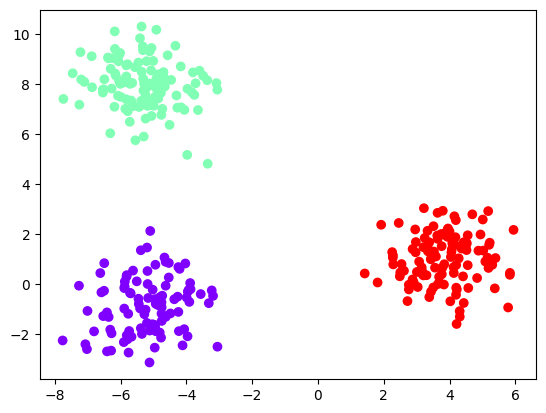

In [19]:
plt.scatter(X_test[:,0], X_test[:,1], c = y_pred, cmap = 'rainbow')

In [20]:
# Other ways to find k value
# 1. kneelocator
# 2. silhouette score

In [28]:
# kneelocator method
%pip install kneed

  Using cached kneed-0.8.6-py3-none-any.whl.metadata (6.4 kB)
Using cached kneed-0.8.6-py3-none-any.whl (10 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from kneed import KneeLocator

In [30]:
k1 = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [32]:
print(k1.elbow)

3


In [33]:
# Method 2 using silhouette score
from sklearn.metrics import silhouette_score

In [34]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [35]:
silhouette_coefficients

[0.5641710352354402,
 0.7965891578246209,
 0.6474216970206766,
 0.4799434420776615,
 0.49962961447736326,
 0.3482520444208724,
 0.3270369685395873,
 0.3290234314747327,
 0.33773789301384705]

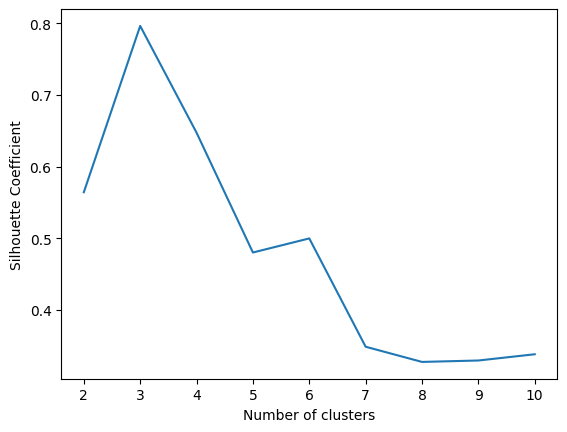

In [36]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

In [ ]:
# Therefore the peak value from the graph is taken as a k value for the k-means algorithm. In this case, it is 3.